In [3]:
%matplotlib inline

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [4]:
roster_2020 = pd.read_csv("cowboys_roster_2020.csv")
roster_2021 = pd.read_csv("cowboys_roster_2021.csv")
roster_2022 = pd.read_csv("cowboys_roster_2022.csv")
roster_2023 = pd.read_csv("cowboys_roster_2023.csv")
roster_2024 = pd.read_csv("cowboys_roster_2024.csv")
roster_2025 = pd.read_csv("cowboys_roster_2025.csv")
roster_2026 = pd.read_csv("cowboys_roster_2026.csv")

In [5]:
rosters = pd.concat([
    roster_2020,
    roster_2021,
    roster_2022,
    roster_2023,
    roster_2024,
    roster_2025,
    roster_2026
])

print("Rows:", len(rosters))

Rows: 508


In [6]:
rosters = rosters[['season', 'team', 'player', 'position']]

print(rosters.head())

   season team             player position
0    2020  DAL       Bradlee Anae       DE
1    2020  DAL          Eli Ankou       DT
2    2020  DAL  Dorance Armstrong       LB
3    2020  DAL     Chidobe Awuzie       DB
4    2020  DAL         Blake Bell       TE


In [7]:
rosters = rosters.dropna(subset=['player'])

rosters = rosters.drop_duplicates(subset=['season', 'team', 'player'])

print("Rows after cleaning:", len(rosters))

Rows after cleaning: 508


In [8]:
g = nx.Graph() # Build the graph

for index, row in rosters.iterrows():
    g.add_node(row['player'], name=row['player'], position=row['position'])

In [9]:
for season, group in rosters.groupby('season'):

    players = list(group['player'])

    i = 0

    for left_player in players:
        for right_player in players[i+1:]:

            weight = g.get_edge_data(left_player, right_player, {"weight": 0})["weight"]

            g.add_edge(left_player, right_player, weight=weight + 1)

        i += 1

In [10]:
print("Nodes:", len(g.nodes))
print("Edges:", len(g.edges))
print("Self loops:", nx.number_of_selfloops(g))

Nodes: 265
Edges: 13577
Self loops: 0


In [11]:
missing_names = 0

for u in g.nodes:
    if 'name' not in g.nodes[u]:
        missing_names += 1

print("Nodes missing names:", missing_names)

Nodes missing names: 0


In [12]:
top_k = 20

centrality_degree = nx.degree_centrality(g)

for u in sorted(centrality_degree, key=centrality_degree.get, reverse=True)[:top_k]:
    print(g.nodes[u]['name'], centrality_degree[u], g.degree(u))

CeeDee Lamb 1.0 264
Dak Prescott 1.0 264
Terence Steele 1.0 264
Bryan Anger 0.8712121212121212 230
Malik Hooker 0.8712121212121212 230
Trevon Diggs 0.8522727272727273 225
C.J. Goodwin 0.8522727272727273 225
Donovan Wilson 0.8522727272727273 225
Markquese Bell 0.7575757575757576 200
DaRon Bland 0.7575757575757576 200
Jake Ferguson 0.7575757575757576 200
Tyler Smith 0.7575757575757576 200
Zack Martin 0.7234848484848485 191
Malik Davis 0.7045454545454546 186
Osa Odighizuwa 0.6818181818181819 180
Ezekiel Elliott 0.6780303030303031 179
Rico Dowdle 0.6628787878787878 175
Demarcus Lawrence 0.6628787878787878 175
Jourdan Lewis 0.6628787878787878 175
Brandon Aubrey 0.6439393939393939 170


In [13]:
top_players = []

for u in sorted(centrality_degree, key=centrality_degree.get, reverse=True)[:10]:
    top_players.append([
        g.nodes[u]['name'],
        g.nodes[u]['position'],
        g.degree(u),
        centrality_degree[u]
    ])

top_players_df = pd.DataFrame(
    top_players,
    columns=['Player', 'Position', 'Unique Teammates', 'Degree Centrality']
)

top_players_df

,Player,Position,Unique Teammates,Degree Centrality
0,CeeDee Lamb,WR,264,1.000000
1,Dak Prescott,QB,264,1.000000
2,Terence Steele,OT,264,1.000000
3,Bryan Anger,P,230,0.871212
4,Malik Hooker,DB,230,0.871212
5,Trevon Diggs,DB,225,0.852273
6,C.J. Goodwin,DB,225,0.852273
7,Donovan Wilson,DB,225,0.852273
8,Markquese Bell,DB,200,0.757576
9,DaRon Bland,DB,200,0.757576


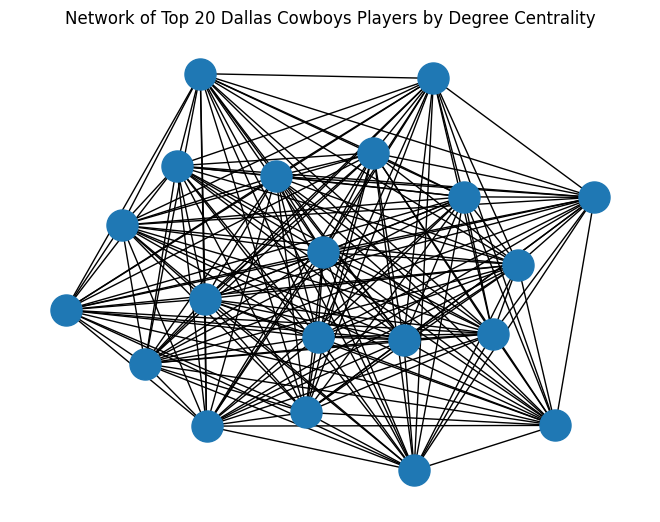

In [14]:
top_nodes = sorted(
    centrality_degree,
    key=centrality_degree.get,
    reverse=True
)[:20]

top_graph = g.subgraph(top_nodes)

nx.draw(
    top_graph,
    with_labels=False,
    node_size=500
)

plt.title("Network of Top 20 Dallas Cowboys Players by Degree Centrality")
plt.show()

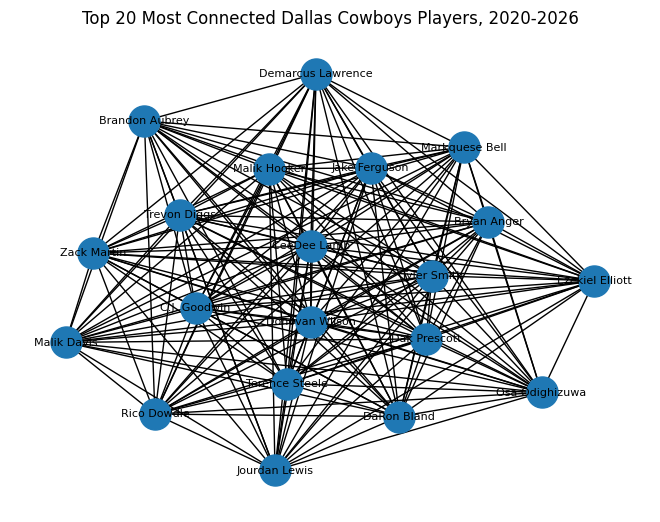

In [15]:
labels = {}

for u in top_graph.nodes:
    labels[u] = g.nodes[u]['name']

nx.draw(
    top_graph,
    labels=labels,
    with_labels=True,
    node_size=500,
    font_size=8
)

plt.title("Top 20 Most Connected Dallas Cowboys Players, 2020-2026")
plt.show()